# End-to-End Machine Learning Pipeline — Research & Industry Style

**Objective:** Build one reproducible binary-classification ML pipeline from dataset creation → data audit → EDA → statistical checks → preprocessing → baseline → model comparison → cross-validation → hyperparameter tuning → final evaluation → explainability → model export → inference.

### Pipeline
1. Problem definition & reproducibility
2. Dataset creation
3. Dataset audit: shape, schema, head, tail, info, describe
4. Data quality: missing values, duplicates, unique values, invalid ranges
5. Exploratory data analysis
6. Outlier analysis
7. Correlation + heatmap
8. Statistical target analysis
9. Leakage-aware train/test split
10. Preprocessing with `Pipeline` + `ColumnTransformer`
11. Baseline model
12. Multiple ML models
13. Cross-validation & model comparison
14. Hyperparameter tuning
15. Final test evaluation
16. Confusion matrix, ROC, PR curve, calibration
17. Feature importance / permutation importance
18. Error analysis
19. Model persistence
20. Single-row inference

## 0. Problem Definition

We will predict whether a customer will **churn** (`1`) or **stay** (`0`).

This dataset is intentionally generated so the notebook is:
- self-contained
- reproducible
- free from external download dependencies
- suitable for GitHub training/portfolio use

> In a real research project, replace the synthetic-data section with the approved real dataset and preserve the rest of the pipeline.

In [1]:
# Core imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn import set_config

set_config(display="diagram")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Environment ready.")

Environment ready.


## 1. Create a Reproducible Dataset

In [2]:
# Create a realistic mixed-type customer churn dataset
rng = np.random.default_rng(RANDOM_STATE)
n = 2500

age = rng.integers(18, 70, n)
income = np.clip(rng.normal(65000, 22000, n), 18000, 180000)
tenure_months = rng.integers(1, 96, n)
monthly_spend = np.clip(rng.normal(85, 30, n), 20, 250)
support_tickets = rng.poisson(2.2, n)
satisfaction_score = np.clip(rng.normal(7.2, 1.7, n), 1, 10)
login_frequency = np.clip(rng.normal(18, 7, n), 1, 40)
avg_session_minutes = np.clip(rng.normal(22, 9, n), 3, 60)

region = rng.choice(
    ["North", "South", "East", "West"],
    size=n,
    p=[0.25, 0.28, 0.22, 0.25]
)
contract = rng.choice(
    ["Monthly", "Annual", "Two Year"],
    size=n,
    p=[0.50, 0.32, 0.18]
)
payment_method = rng.choice(
    ["Card", "UPI", "Bank Transfer", "Wallet"],
    size=n,
    p=[0.40, 0.30, 0.20, 0.10]
)
device = rng.choice(
    ["Android", "iOS", "Web"],
    size=n,
    p=[0.45, 0.35, 0.20]
)

# Latent churn signal: higher support, lower satisfaction/activity,
# shorter tenure and month-to-month contracts increase churn likelihood.
logit = (
    -0.55
    + 0.018 * support_tickets
    - 0.42 * (satisfaction_score - 7)
    - 0.012 * (tenure_months - 36)
    - 0.035 * (login_frequency - 18)
    + 0.010 * (monthly_spend - 85)
    + 0.90 * (contract == "Monthly")
    + 0.30 * (payment_method == "Wallet")
)

prob_churn = 1 / (1 + np.exp(-logit))
churn = rng.binomial(1, prob_churn)

df = pd.DataFrame({
    "age": age,
    "income": income,
    "tenure_months": tenure_months,
    "monthly_spend": monthly_spend,
    "support_tickets": support_tickets,
    "satisfaction_score": satisfaction_score,
    "login_frequency": login_frequency,
    "avg_session_minutes": avg_session_minutes,
    "region": region,
    "contract": contract,
    "payment_method": payment_method,
    "device": device,
    "churn": churn
})

# Intentionally introduce a small amount of missing data for cleaning/preprocessing practice.
for col in ["income", "satisfaction_score", "region", "payment_method"]:
    idx = rng.choice(df.index, size=int(0.02 * len(df)), replace=False)
    df.loc[idx, col] = np.nan

# Intentionally add a few exact duplicates so the notebook demonstrates duplicate handling.
df = pd.concat([df, df.iloc[:8]], ignore_index=True)

os.makedirs("data", exist_ok=True)
raw_path = "data/customer_churn_raw.csv"
df.to_csv(raw_path, index=False)

print(f"Dataset saved to: {raw_path}")
print("Raw shape:", df.shape)
df.head()

Dataset saved to: data/customer_churn_raw.csv
Raw shape: (2508, 13)


,age,income,tenure_months,monthly_spend,support_tickets,satisfaction_score,login_frequency,avg_session_minutes,region,contract,payment_method,device,churn
0,22,"18,000.000",26,105.509,4,8.015,16.667,3.000,North,Annual,Card,iOS,1
1,58,"34,683.796",20,57.661,1,6.936,15.721,19.070,East,Annual,Bank Transfer,iOS,0
2,52,"25,166.389",8,136.943,1,7.185,5.771,21.967,West,Monthly,NaN,Web,1
3,40,"18,000.000",30,101.089,0,7.911,18.429,17.975,South,Monthly,Card,Web,1
4,40,"38,702.103",49,73.425,2,9.599,21.657,41.542,South,Monthly,UPI,iOS,1


## 2. Dataset Audit

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\n--- HEAD ---")
display(df.head())

print("\n--- TAIL ---")
display(df.tail())

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIBE: NUMERIC ---")
display(df.describe().T)

print("\n--- DESCRIBE: ALL ---")
display(df.describe(include="all").T)

Shape: (2508, 13)

Columns:
['age', 'income', 'tenure_months', 'monthly_spend', 'support_tickets', 'satisfaction_score', 'login_frequency', 'avg_session_minutes', 'region', 'contract', 'payment_method', 'device', 'churn']

--- HEAD ---


,age,income,tenure_months,monthly_spend,support_tickets,satisfaction_score,login_frequency,avg_session_minutes,region,contract,payment_method,device,churn
0,22,"18,000.000",26,105.509,4,8.015,16.667,3.000,North,Annual,Card,iOS,1
1,58,"34,683.796",20,57.661,1,6.936,15.721,19.070,East,Annual,Bank Transfer,iOS,0
2,52,"25,166.389",8,136.943,1,7.185,5.771,21.967,West,Monthly,NaN,Web,1
3,40,"18,000.000",30,101.089,0,7.911,18.429,17.975,South,Monthly,Card,Web,1
4,40,"38,702.103",49,73.425,2,9.599,21.657,41.542,South,Monthly,UPI,iOS,1



--- TAIL ---


,age,income,tenure_months,monthly_spend,support_tickets,satisfaction_score,login_frequency,avg_session_minutes,region,contract,payment_method,device,churn
2503,40,"18,000.000",30,101.089,0,7.911,18.429,17.975,South,Monthly,Card,Web,1
2504,40,"38,702.103",49,73.425,2,9.599,21.657,41.542,South,Monthly,UPI,iOS,1
2505,62,"94,149.025",17,64.952,5,6.486,18.473,38.419,East,Annual,UPI,Android,1
2506,22,"64,022.404",26,92.704,0,5.208,30.384,31.295,North,Monthly,Card,iOS,1
2507,54,"93,392.403",2,34.868,3,7.046,10.968,13.672,South,Annual,Card,Web,0



--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 2508 entries, 0 to 2507
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  2508 non-null   int64  
 1   income               2458 non-null   float64
 2   tenure_months        2508 non-null   int64  
 3   monthly_spend        2508 non-null   float64
 4   support_tickets      2508 non-null   int64  
 5   satisfaction_score   2458 non-null   float64
 6   login_frequency      2508 non-null   float64
 7   avg_session_minutes  2508 non-null   float64
 8   region               2458 non-null   str    
 9   contract             2508 non-null   str    
 10  payment_method       2457 non-null   str    
 11  device               2508 non-null   str    
 12  churn                2508 non-null   int64  
dtypes: float64(5), int64(4), str(4)
memory usage: 309.1 KB

--- DESCRIBE: NUMERIC ---


,count,mean,std,min,25%,50%,75%,max
age,"2,508.000",43.398,15.002,18.000,30.000,43.000,56.000,69.000
income,"2,458.000","64,805.870","21,879.025","18,000.000","49,900.471","65,179.035","79,559.715","132,947.268"
tenure_months,"2,508.000",47.629,26.973,1.000,24.000,47.000,70.000,95.000
monthly_spend,"2,508.000",85.908,29.761,20.000,65.589,84.931,106.035,183.816
support_tickets,"2,508.000",2.211,1.474,0.000,1.000,2.000,3.000,9.000
satisfaction_score,"2,458.000",7.239,1.624,1.662,6.151,7.235,8.399,10.000
login_frequency,"2,508.000",18.433,7.100,1.000,13.325,18.468,23.266,40.000
avg_session_minutes,"2,508.000",21.948,8.725,3.000,16.021,21.803,27.866,49.088
churn,"2,508.000",0.419,0.494,0.000,0.000,0.000,1.000,1.000



--- DESCRIBE: ALL ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"2,508.000",NaN,NaN,NaN,43.398,15.002,18.000,30.000,43.000,56.000,69.000
income,"2,458.000",NaN,NaN,NaN,"64,805.870","21,879.025","18,000.000","49,900.471","65,179.035","79,559.715","132,947.268"
tenure_months,"2,508.000",NaN,NaN,NaN,47.629,26.973,1.000,24.000,47.000,70.000,95.000
monthly_spend,"2,508.000",NaN,NaN,NaN,85.908,29.761,20.000,65.589,84.931,106.035,183.816
support_tickets,"2,508.000",NaN,NaN,NaN,2.211,1.474,0.000,1.000,2.000,3.000,9.000
satisfaction_score,"2,458.000",NaN,NaN,NaN,7.239,1.624,1.662,6.151,7.235,8.399,10.000
login_frequency,"2,508.000",NaN,NaN,NaN,18.433,7.100,1.000,13.325,18.468,23.266,40.000
avg_session_minutes,"2,508.000",NaN,NaN,NaN,21.948,8.725,3.000,16.021,21.803,27.866,49.088
region,2458,4,South,668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract,2508,3,Monthly,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Data types and unique values
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
audit["memory_bytes"] = df.memory_usage(deep=True).drop("Index")
display(audit.sort_values("missing_pct", ascending=False))

,dtype,missing_count,missing_pct,n_unique,memory_bytes
payment_method,str,51,2.030,5,34721
satisfaction_score,float64,50,1.990,2321,20064
region,str,50,1.990,5,31760
income,float64,50,1.990,2410,20064
age,int64,0,0.000,52,20064
support_tickets,int64,0,0.000,10,20064
monthly_spend,float64,0,0.000,2467,20064
tenure_months,int64,0,0.000,95,20064
login_frequency,float64,0,0.000,2484,20064
avg_session_minutes,float64,0,0.000,2452,20064


## 3. Data Quality Checks

In [5]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})
display(missing_report[missing_report["missing_count"] > 0])

# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Target balance
print("\nTarget distribution:")
display(df["churn"].value_counts(dropna=False).rename("count").to_frame())

print("\nTarget percentage:")
display((df["churn"].value_counts(normalize=True) * 100).round(2).rename("percentage").to_frame())

,missing_count,missing_pct
payment_method,51,2.033
satisfaction_score,50,1.994
region,50,1.994
income,50,1.994


Duplicate rows: 8

Target distribution:


,count
churn,
0,1456
1,1052



Target percentage:


,percentage
churn,
0,58.050
1,41.950


In [6]:
# Domain/range checks
range_checks = {
    "age_invalid": ((df["age"] < 18) | (df["age"] > 100)).sum(),
    "income_invalid": (df["income"] < 0).sum(),
    "tenure_invalid": (df["tenure_months"] < 0).sum(),
    "monthly_spend_invalid": (df["monthly_spend"] < 0).sum(),
    "satisfaction_invalid": ((df["satisfaction_score"] < 1) | (df["satisfaction_score"] > 10)).sum(),
    "login_frequency_invalid": (df["login_frequency"] < 0).sum(),
}
display(pd.Series(range_checks, name="invalid_count").to_frame())

,invalid_count
age_invalid,0
income_invalid,0
tenure_invalid,0
monthly_spend_invalid,0
satisfaction_invalid,0
login_frequency_invalid,0


In [7]:
# Remove exact duplicate observations before EDA/modeling.
before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df_clean)} duplicate rows.")
print("Clean shape:", df_clean.shape)

df_clean.to_csv("data/customer_churn_clean.csv", index=False)

Removed 8 duplicate rows.
Clean shape: (2500, 13)


## 4. Exploratory Data Analysis (EDA)

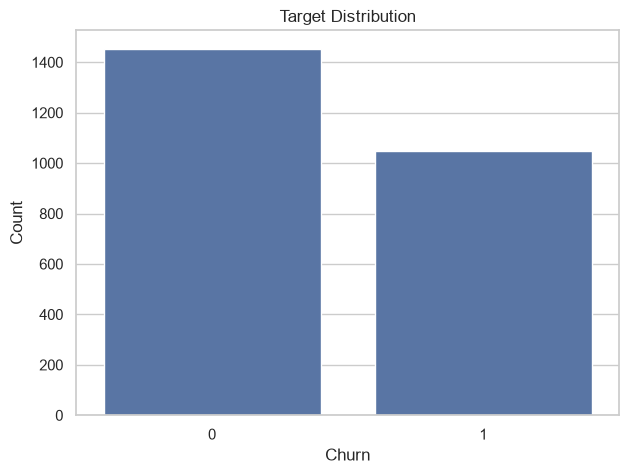

In [8]:
# Theme for notebook plots only
sns.set_theme(style="whitegrid")

# Target count plot
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="churn")
plt.title("Target Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

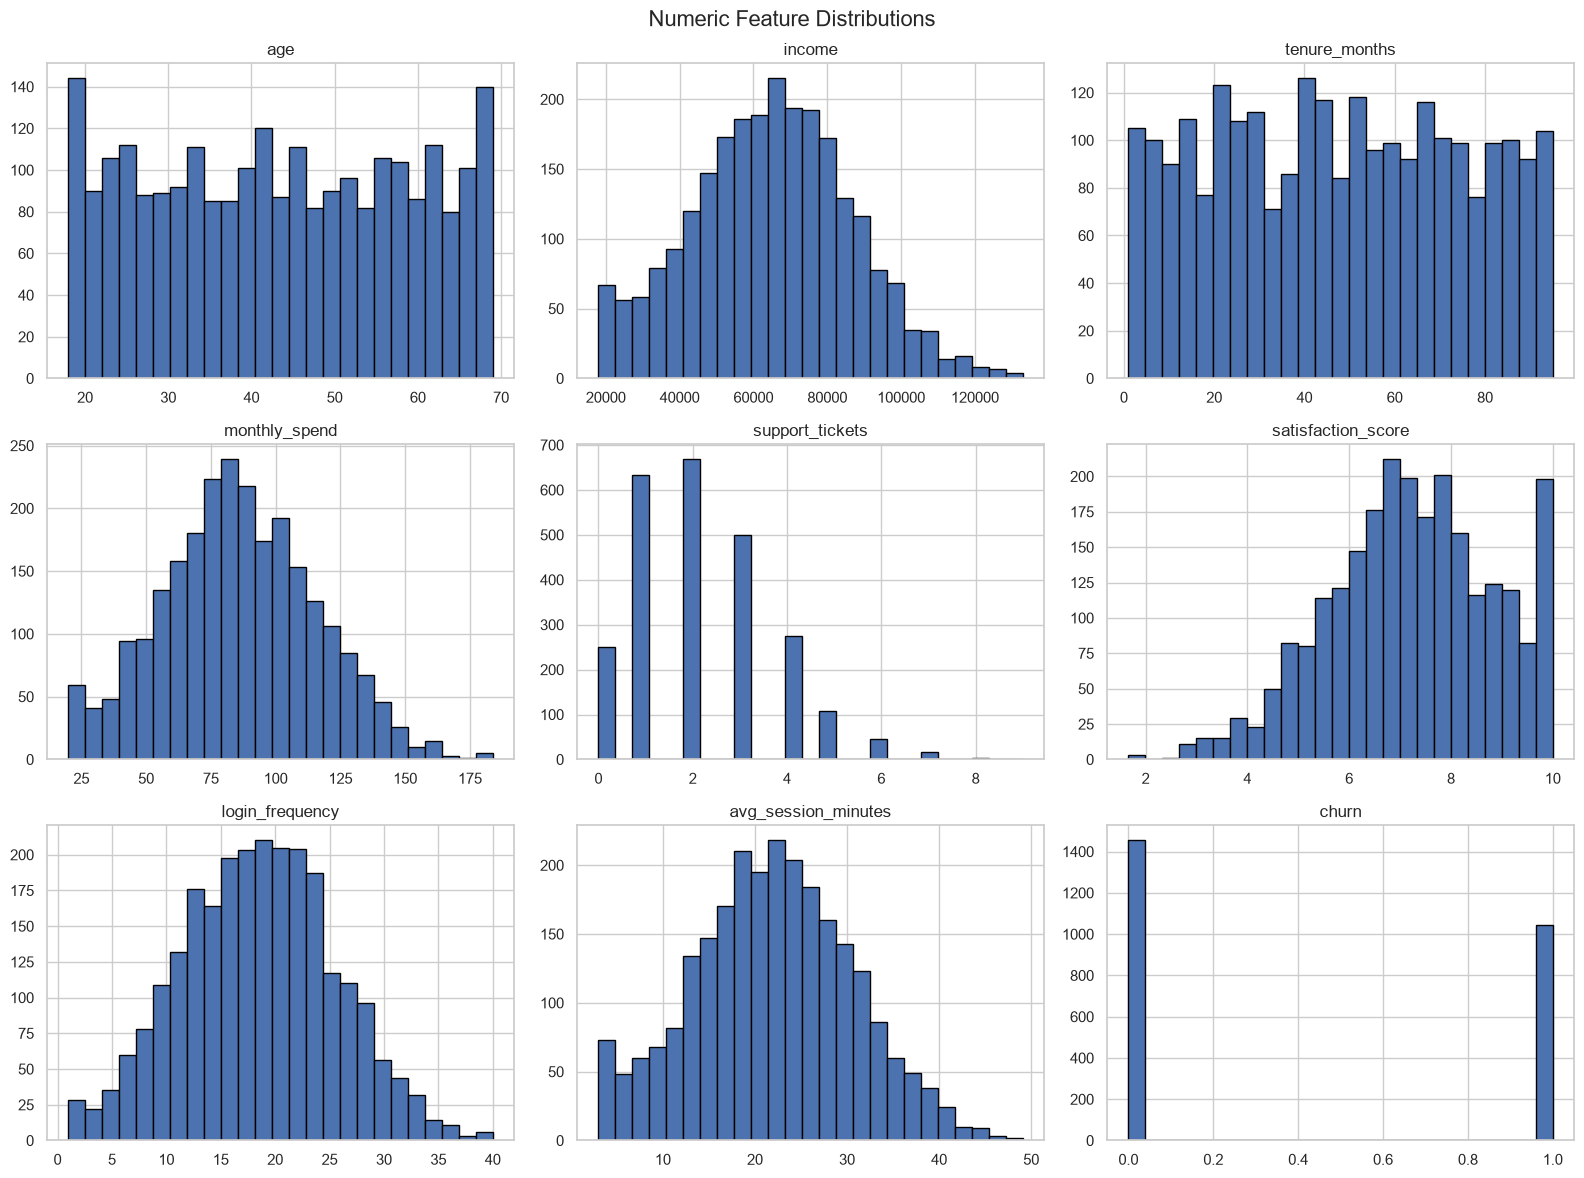

In [9]:
# Histograms for numeric variables
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

df_clean[numeric_cols].hist(
    figsize=(16, 12),
    bins=25,
    edgecolor="black"
)
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

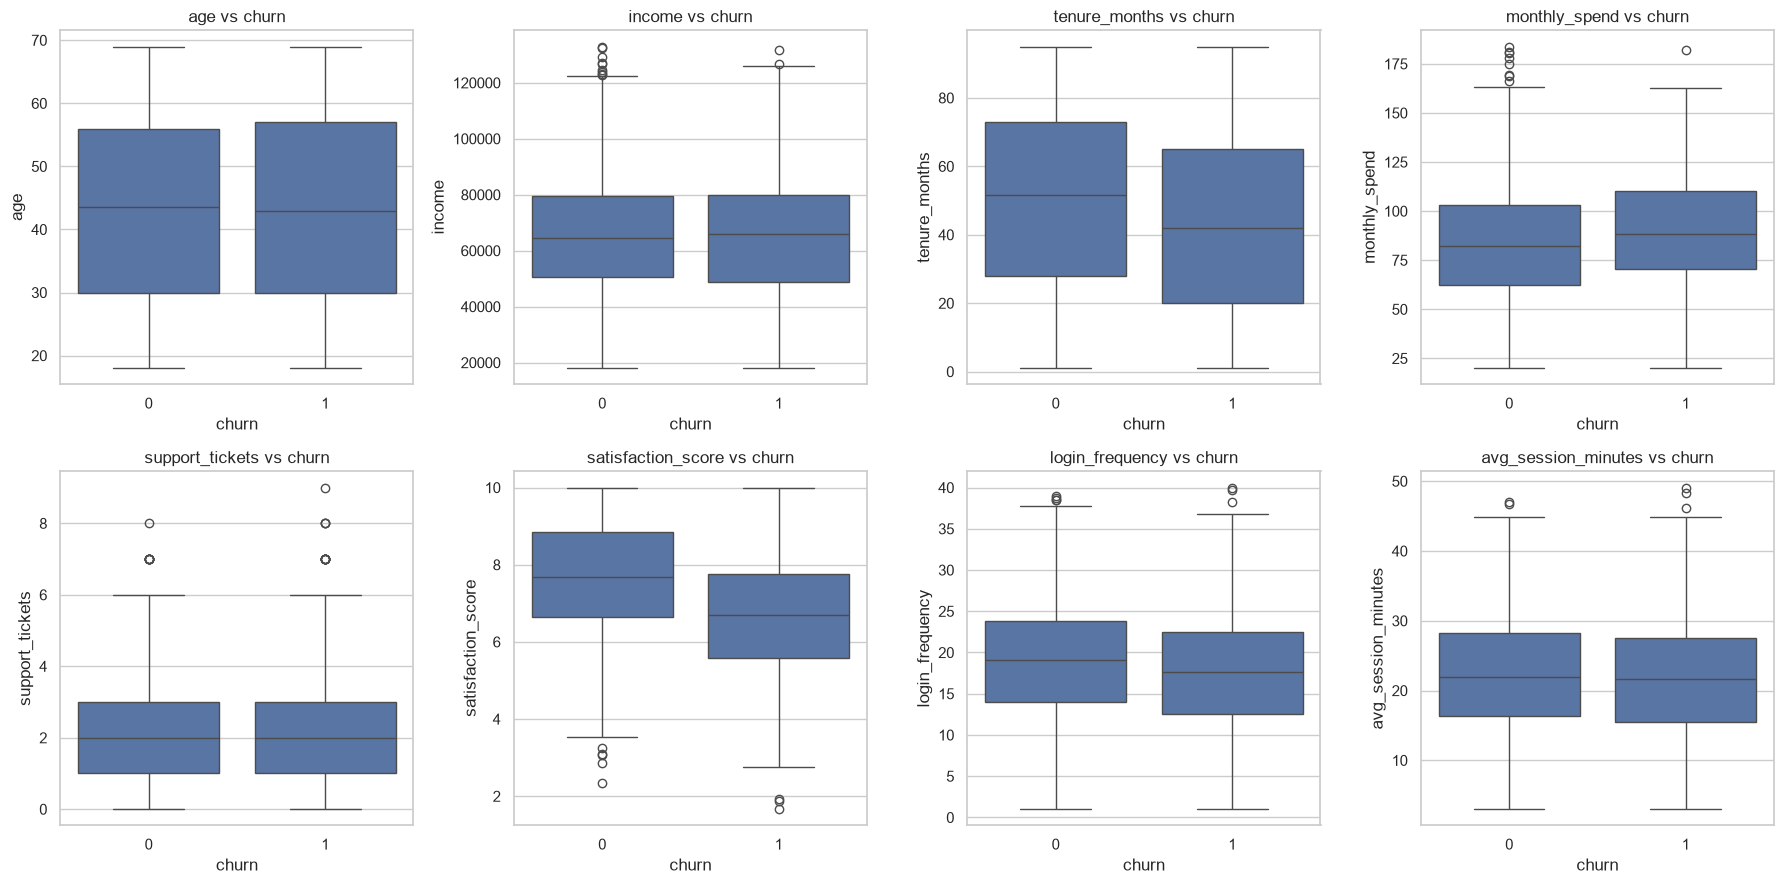

In [10]:
# Boxplots for numeric features against target
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

num_features = [c for c in numeric_cols if c != "churn"]

for ax, col in zip(axes, num_features):
    sns.boxplot(data=df_clean, x="churn", y=col, ax=ax)
    ax.set_title(f"{col} vs churn")

for ax in axes[len(num_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

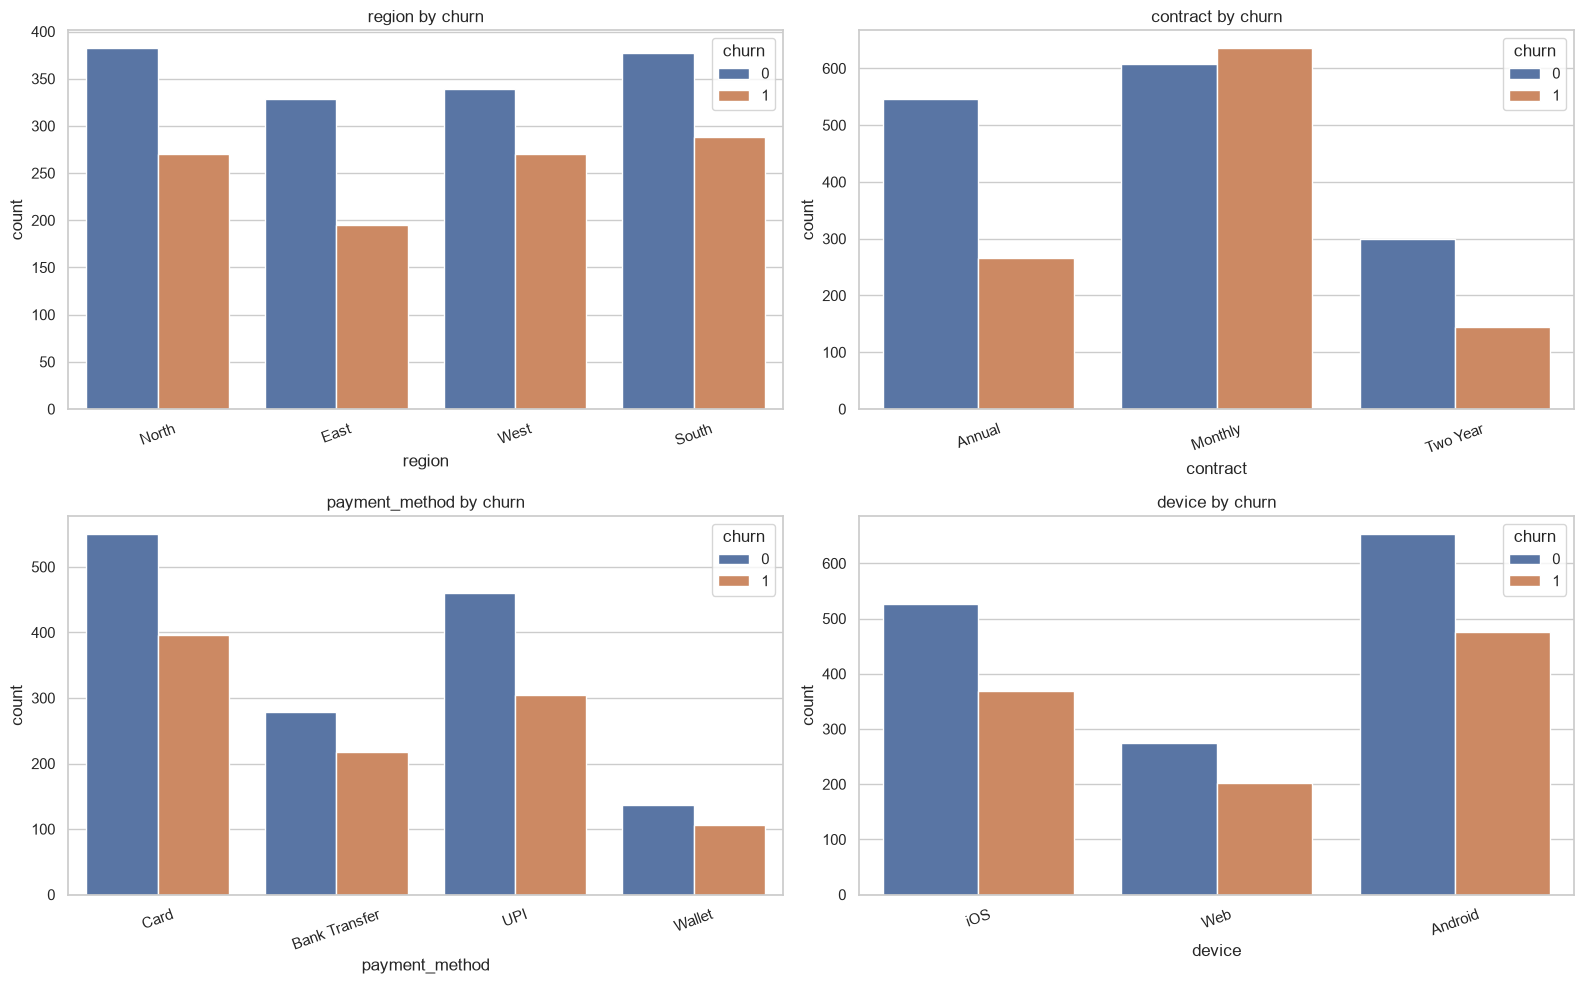

In [11]:
# Categorical feature frequency plots
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="churn",
        ax=ax
    )
    ax.set_title(f"{col} by churn")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

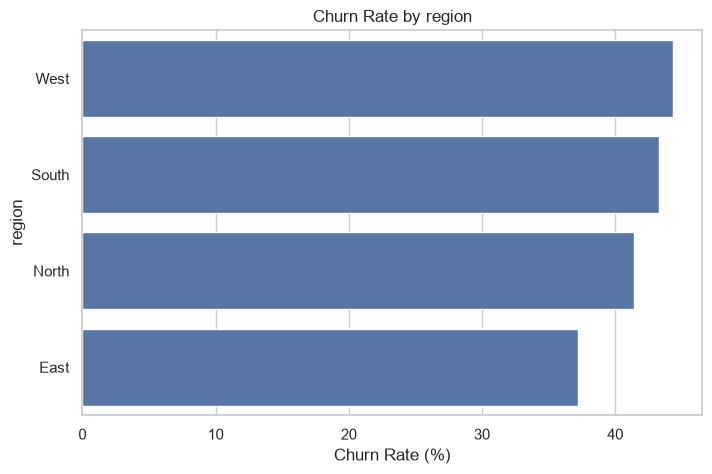

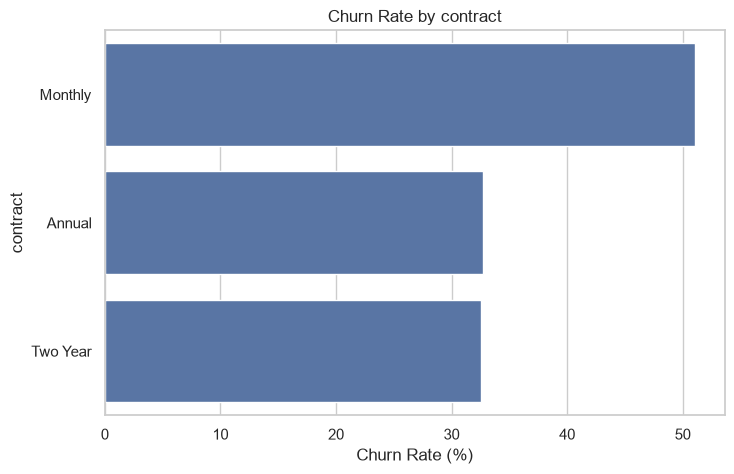

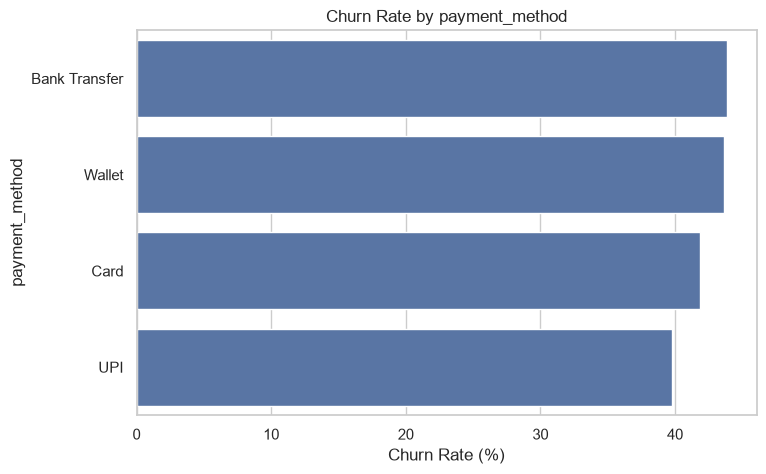

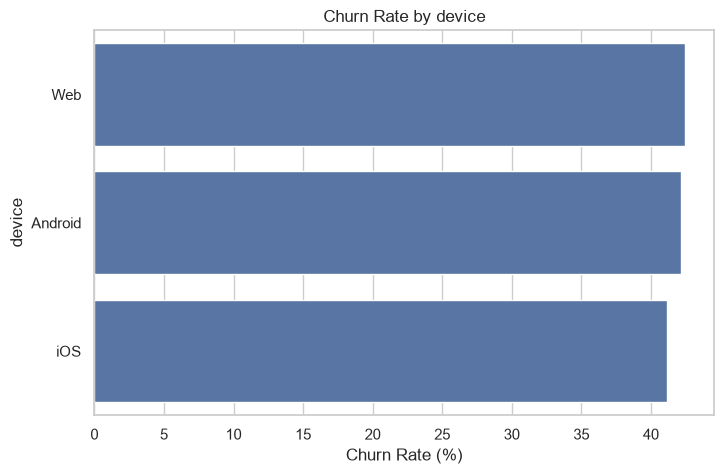

In [12]:
# Churn rate by categorical feature
for col in categorical_cols:
    rate = (
        df_clean.groupby(col, dropna=False)["churn"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(2)
    )
    plt.figure(figsize=(8, 5))
    sns.barplot(x=rate.values, y=rate.index)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel("Churn Rate (%)")
    plt.ylabel(col)
    plt.show()

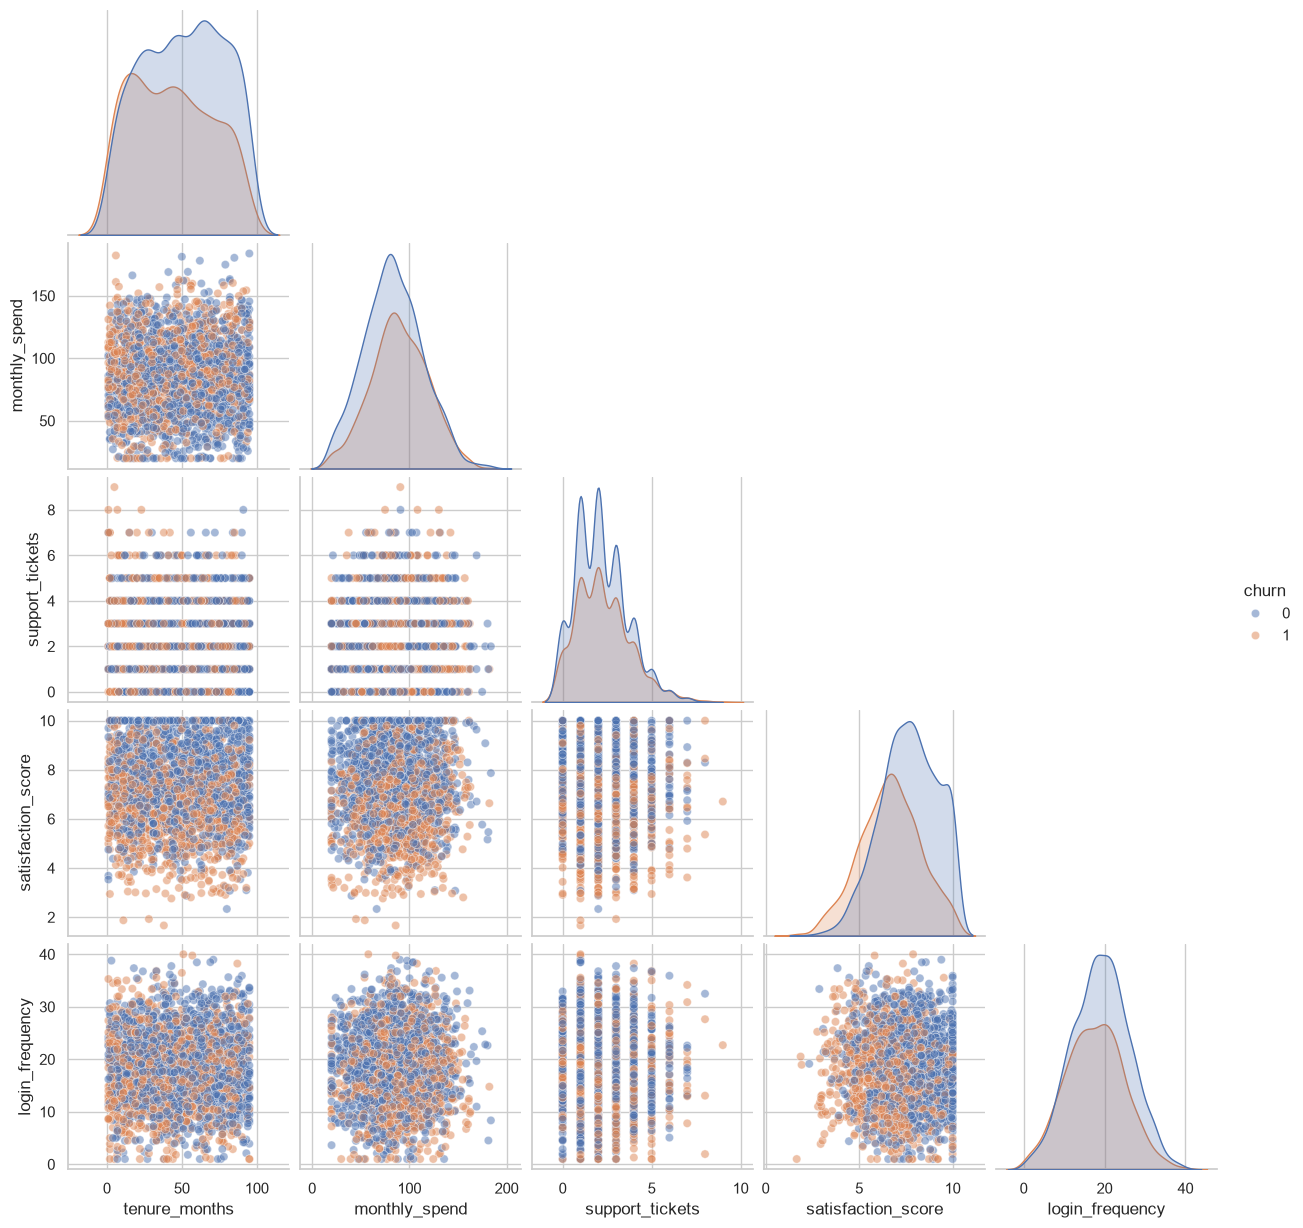

In [13]:
# Pairwise view of selected numeric variables
pair_cols = [
    "tenure_months",
    "monthly_spend",
    "support_tickets",
    "satisfaction_score",
    "login_frequency",
    "churn"
]
sns.pairplot(
    df_clean[pair_cols],
    hue="churn",
    corner=True,
    plot_kws={"alpha": 0.5}
)
plt.show()

## 5. Outlier Analysis

In [14]:
# IQR-based outlier counts
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_report = pd.Series(
    {col: iqr_outlier_count(df_clean[col]) for col in num_features},
    name="iqr_outlier_count"
).sort_values(ascending=False)

display(outlier_report.to_frame())

,iqr_outlier_count
support_tickets,22
income,10
monthly_spend,8
login_frequency,7
satisfaction_score,5
avg_session_minutes,5
tenure_months,0
age,0


## 6. Correlation & Heatmap

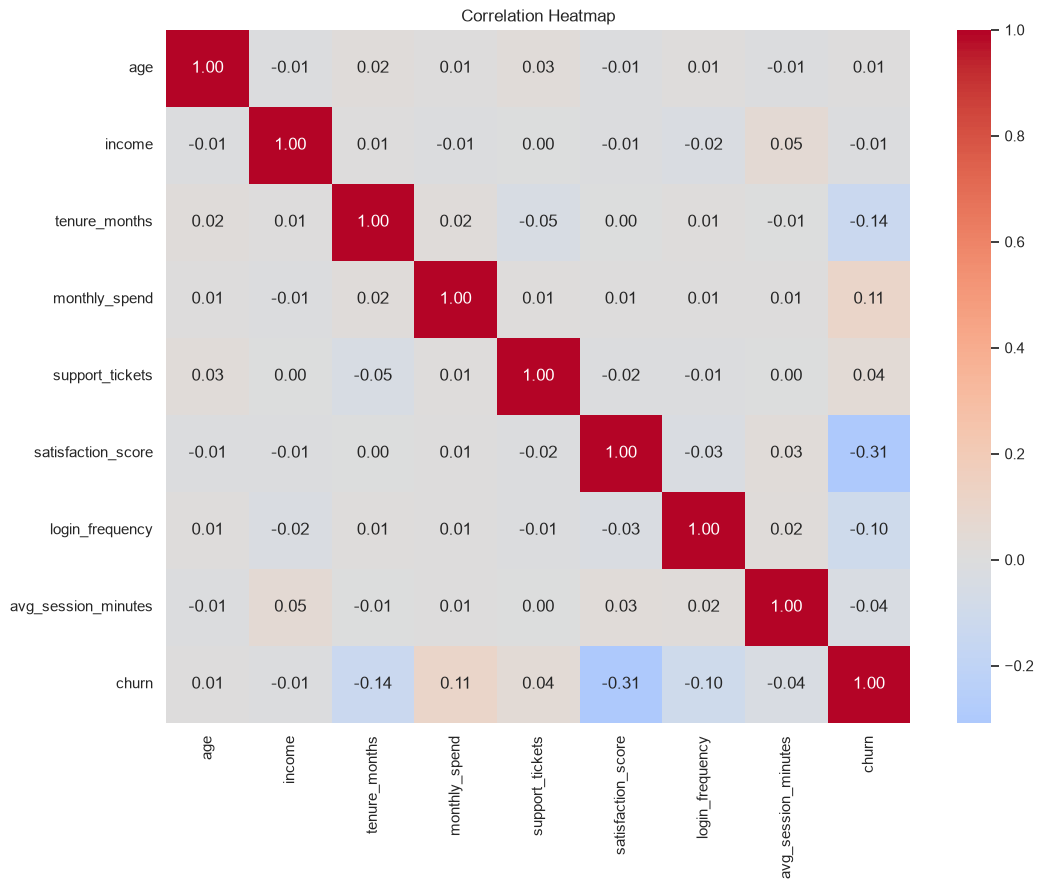

Correlation with target:


,correlation_with_churn
satisfaction_score,-0.308
tenure_months,-0.137
monthly_spend,0.105
login_frequency,-0.101
support_tickets,0.040
avg_session_minutes,-0.035
income,-0.014
age,0.007


In [15]:
corr = df_clean.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with target:")
display(
    corr["churn"]
    .drop("churn")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("correlation_with_churn")
)